In [1]:
print('Hello')

Hello


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05822.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05902.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_06016.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05876.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_06068.JPG
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05859.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05933.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05949.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05880.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_06046.JPG
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05978.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_05809.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Motorbike/2015_06076.jpg
/kaggle/input/datasets/smnahian/lowlight/Images/Mot

In [3]:
from pathlib import Path

DATASET = Path("/kaggle/input/datasets/smnahian/lowlight")

print("Dataset exists:", DATASET.exists())
print("Contents:")

for item in DATASET.iterdir():
    print(item)

Dataset exists: True
Contents:
/kaggle/input/datasets/smnahian/lowlight/Images
/kaggle/input/datasets/smnahian/lowlight/Annotaions


In [4]:
from pathlib import Path
import pandas as pd

DATASET = Path("/kaggle/input/datasets/smnahian/lowlight")

IMAGE_DIR = DATASET / "Images"
ANNOTATION_DIR = DATASET / "Annotaions"
SPLIT_FILE = ANNOTATION_DIR / "imageclasslist.txt"

print("Image directory exists:", IMAGE_DIR.exists())
print("Annotation directory exists:", ANNOTATION_DIR.exists())
print("Split file exists:", SPLIT_FILE.exists())

print("\nImage folders:")
for folder in sorted(IMAGE_DIR.iterdir()):
    print(folder.name)

print("\nAnnotation folders:")
for folder in sorted(ANNOTATION_DIR.iterdir()):
    print(folder.name)

Image directory exists: True
Annotation directory exists: True
Split file exists: True

Image folders:
Bicycle
Boat
Bottle
Bus
Car
Cat
Chair
Cup
Dog
Motorbike
People
Table

Annotation folders:
Bicycle
Boat
Bottle
Bus
Car
Cat
Chair
Cup
Dog
Motorbike
People
Table
imageclasslist.txt


In [5]:
from pathlib import Path
import pandas as pd

DATASET = Path("/kaggle/input/datasets/smnahian/lowlight")
SPLIT_FILE = DATASET / "Annotaions" / "imageclasslist.txt"

# Read the file:
# Data rows are whitespace-separated.
df = pd.read_csv(
    SPLIT_FILE,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["Name", "Class", "Light", "In_Out", "Split"]
)

# Convert numeric columns
df["Class"] = pd.to_numeric(df["Class"], errors="coerce")
df["Light"] = pd.to_numeric(df["Light"], errors="coerce")
df["In_Out"] = pd.to_numeric(df["In_Out"], errors="coerce")
df["Split"] = pd.to_numeric(df["Split"], errors="coerce")

# Remove any invalid rows
df = df.dropna(subset=["Name", "Class", "Split"])

# Convert to integers
df["Class"] = df["Class"].astype(int)
df["Light"] = df["Light"].astype(int)
df["In_Out"] = df["In_Out"].astype(int)
df["Split"] = df["Split"].astype(int)

print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nTotal rows:", len(df))

Columns:
['Name', 'Class', 'Light', 'In_Out', 'Split']

First 5 rows:
             Name  Class  Light  In_Out  Split
0  2015_00001.png      1      2       1      1
1  2015_00002.png      1      6       2      1
2  2015_00003.png      1      5       2      1
3  2015_00004.jpg      1      3       2      1
4  2015_00005.jpg      1      6       2      1

Total rows: 7363


In [6]:
# ExDark class IDs
vehicle_classes = {
    1: "Bicycle",
    2: "Boat",
    4: "Bus",
    5: "Car",
    10: "Motorbike"
}

# Keep only vehicle classes
vehicle_df = df[df["Class"].isin(vehicle_classes.keys())].copy()

# Convert class IDs to names
vehicle_df["Class_Name"] = vehicle_df["Class"].map(vehicle_classes)

# Convert split IDs
split_names = {
    1: "Train",
    2: "Validation",
    3: "Test"
}

vehicle_df["Split_Name"] = vehicle_df["Split"].map(split_names)

print("Total vehicle images:", len(vehicle_df))

print("\nClass counts:")
print(vehicle_df["Class_Name"].value_counts().sort_index())

print("\nSplit counts:")
print(vehicle_df["Split_Name"].value_counts())

print("\nClass × Split:")
print(
    pd.crosstab(
        vehicle_df["Class_Name"],
        vehicle_df["Split_Name"]
    )
)

Total vehicle images: 2999

Class counts:
Class_Name
Bicycle      652
Boat         679
Bus          527
Car          638
Motorbike    503
Name: count, dtype: int64

Split counts:
Split_Name
Train         1250
Test           999
Validation     750
Name: count, dtype: int64

Class × Split:
Split_Name  Test  Train  Validation
Class_Name                         
Bicycle      252    250         150
Boat         279    250         150
Bus          127    250         150
Car          238    250         150
Motorbike    103    250         150


In [7]:
from pathlib import Path

image_dir = DATASET / "Images" / "Boat"
annotation_dir = DATASET / "Annotaions" / "Boat"

# Get first image
images = list(image_dir.glob("*"))
image_file = images[0]

print("Image:")
print(image_file)

# Annotation filename = complete image filename + ".txt"
annotation_file = annotation_dir / (image_file.name + ".txt")

print("\nAnnotation:")
print(annotation_file)

print("\nAnnotation exists:", annotation_file.exists())

if annotation_file.exists():
    print("\nAnnotation content:\n")
    print(annotation_file.read_text(errors="ignore"))

Image:
/kaggle/input/datasets/smnahian/lowlight/Images/Boat/2015_01231.jpg

Annotation:
/kaggle/input/datasets/smnahian/lowlight/Annotaions/Boat/2015_01231.jpg.txt

Annotation exists: True

Annotation content:

% bbGt version=3
Boat 121 603 520 240 0 0 0 0 0 0 0



In [8]:
from pathlib import Path
from collections import Counter

# =========================
# Dataset paths
# =========================

DATASET = Path("/kaggle/input/datasets/smnahian/lowlight")

IMAGE_DIR = DATASET / "Images"
ANNOTATION_DIR = DATASET / "Annotaions"

# Only these 5 classes
VEHICLE_CLASSES = {
    "Bicycle",
    "Boat",
    "Bus",
    "Car",
    "Motorbike"
}

# =========================
# Counters
# =========================

total_images = 0
annotation_found = 0
annotation_missing = 0

images_with_vehicle = 0
images_with_non_vehicle = 0

vehicle_objects = Counter()
non_vehicle_objects = Counter()

missing_annotations = []
empty_annotations = []
invalid_annotations = []

# =========================
# Scan vehicle image folders
# =========================

for class_name in sorted(VEHICLE_CLASSES):

    image_folder = IMAGE_DIR / class_name
    annotation_folder = ANNOTATION_DIR / class_name

    print(f"Scanning {class_name}...")

    for image_file in image_folder.iterdir():

        if not image_file.is_file():
            continue

        total_images += 1

        # Annotation name:
        # 2015_01231.jpg -> 2015_01231.jpg.txt
        annotation_file = annotation_folder / (image_file.name + ".txt")

        if not annotation_file.exists():
            annotation_missing += 1
            missing_annotations.append(str(image_file))
            continue

        annotation_found += 1

        # Read annotation
        lines = annotation_file.read_text(
            errors="ignore"
        ).splitlines()

        objects_in_image = []
        has_vehicle = False
        has_non_vehicle = False

        for line in lines:

            line = line.strip()

            # Skip metadata line
            if not line or line.startswith("%"):
                continue

            parts = line.split()

            # Expected:
            # Class l t w h + 7 values
            if len(parts) < 5:
                invalid_annotations.append(
                    (str(annotation_file), line)
                )
                continue

            object_class = parts[0]

            objects_in_image.append(object_class)

            if object_class in VEHICLE_CLASSES:
                vehicle_objects[object_class] += 1
                has_vehicle = True
            else:
                non_vehicle_objects[object_class] += 1
                has_non_vehicle = True

        if not objects_in_image:
            empty_annotations.append(str(annotation_file))

        if has_vehicle:
            images_with_vehicle += 1

        if has_non_vehicle:
            images_with_non_vehicle += 1


# =========================
# Results
# =========================

print("\n" + "=" * 50)
print("DATASET VALIDATION RESULT")
print("=" * 50)

print(f"\nTotal vehicle-class images: {total_images}")

print(f"Annotations found:          {annotation_found}")
print(f"Annotations missing:        {annotation_missing}")

print(f"\nImages containing vehicle:  {images_with_vehicle}")
print(f"Images containing non-vehicle: {images_with_non_vehicle}")

print("\nVehicle object counts:")
for name, count in vehicle_objects.items():
    print(f"  {name}: {count}")

print("\nNon-vehicle object counts:")
for name, count in non_vehicle_objects.most_common():
    print(f"  {name}: {count}")

print("\nEmpty annotations:", len(empty_annotations))
print("Invalid annotations:", len(invalid_annotations))

# Show missing annotation examples
if missing_annotations:
    print("\nFirst 10 missing annotation examples:")
    for x in missing_annotations[:10]:
        print(" ", x)

# Show invalid annotation examples
if invalid_annotations:
    print("\nFirst 10 invalid annotation examples:")
    for x in invalid_annotations[:10]:
        print(" ", x)

Scanning Bicycle...
Scanning Boat...
Scanning Bus...
Scanning Car...
Scanning Motorbike...

DATASET VALIDATION RESULT

Total vehicle-class images: 2999
Annotations found:          2998
Annotations missing:        1

Images containing vehicle:  2997
Images containing non-vehicle: 1204

Vehicle object counts:
  Bicycle: 1077
  Car: 2501
  Motorbike: 1036
  Bus: 689
  Boat: 1377

Non-vehicle object counts:
  People: 3489
  Chair: 123
  Table: 61
  Dog: 22
  Bottle: 21
  Cup: 11
  Cat: 10

Empty annotations: 1
Invalid annotations: 0

First 10 missing annotation examples:
  /kaggle/input/datasets/smnahian/lowlight/Images/Bicycle/2015_00391.JPG


In [9]:
# Check images with missing/empty annotations

print("Missing annotation images:")
for x in missing_annotations:
    print(x)

print("\nEmpty annotation files:")
for x in empty_annotations:
    print(x)

Missing annotation images:
/kaggle/input/datasets/smnahian/lowlight/Images/Bicycle/2015_00391.JPG

Empty annotation files:
/kaggle/input/datasets/smnahian/lowlight/Annotaions/Motorbike/2015_05894.jpg.txt


In [10]:
from pathlib import Path

# =========================
# Paths
# =========================

DATASET = Path("/kaggle/input/datasets/smnahian/lowlight")

IMAGE_DIR = DATASET / "Images"
ANNOTATION_DIR = DATASET / "Annotaions"

# Output directory
OUTPUT_DIR = Path("/kaggle/working/filtered_annotations")

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# Vehicle classes
# =========================

VEHICLE_CLASSES = {
    "Bicycle",
    "Boat",
    "Bus",
    "Car",
    "Motorbike"
}


# =========================
# Counters
# =========================

total_annotations = 0
filtered_annotations = 0
removed_objects = 0
images_with_vehicle = 0
empty_after_filtering = 0


# =========================
# Process annotations
# =========================

for class_folder in sorted(VEHICLE_CLASSES):

    input_folder = ANNOTATION_DIR / class_folder

    # Create corresponding output folder
    output_folder = OUTPUT_DIR / class_folder
    output_folder.mkdir(parents=True, exist_ok=True)

    print(f"Processing {class_folder}...")

    # Find all annotation files
    for annotation_file in input_folder.glob("*.txt"):

        # Read annotation
        lines = annotation_file.read_text(
            errors="ignore"
        ).splitlines()

        total_annotations += 1

        filtered_lines = []

        for line in lines:

            line = line.strip()

            # Keep metadata line
            if line.startswith("%"):
                filtered_lines.append(line)
                continue

            # Skip blank lines
            if not line:
                continue

            parts = line.split()

            # Need at least class + l + t + w + h
            if len(parts) < 5:
                continue

            object_class = parts[0]

            # Keep only vehicle objects
            if object_class in VEHICLE_CLASSES:

                filtered_lines.append(line)
                filtered_annotations += 1

            else:

                removed_objects += 1

        # Save filtered annotation
        output_file = output_folder / annotation_file.name

        if len(filtered_lines) > 1:
            images_with_vehicle += 1

        else:
            empty_after_filtering += 1

        output_file.write_text(
            "\n".join(filtered_lines)
        )


# =========================
# Results
# =========================

print("\n" + "=" * 50)
print("ANNOTATION FILTERING COMPLETE")
print("=" * 50)

print(f"Original annotation files processed: {total_annotations}")
print(f"Vehicle annotations kept:             {filtered_annotations}")
print(f"Non-vehicle annotations removed:      {removed_objects}")
print(f"Files containing vehicle objects:     {images_with_vehicle}")
print(f"Files empty after filtering:          {empty_after_filtering}")

print("\nFiltered annotations saved to:")
print(OUTPUT_DIR)

Processing Bicycle...
Processing Boat...
Processing Bus...
Processing Car...
Processing Motorbike...

ANNOTATION FILTERING COMPLETE
Original annotation files processed: 2999
Vehicle annotations kept:             6684
Non-vehicle annotations removed:      3740
Files containing vehicle objects:     2998
Files empty after filtering:          1

Filtered annotations saved to:
/kaggle/working/filtered_annotations


In [11]:
# Check the same Boat annotation we inspected earlier

original_file = (
    ANNOTATION_DIR
    / "Boat"
    / "2015_00658.jpg.txt"
)

filtered_file = (
    OUTPUT_DIR
    / "Boat"
    / "2015_00658.jpg.txt"
)

print("Original annotation:\n")
print(original_file.read_text(errors="ignore"))

print("\n" + "=" * 50)

print("Filtered annotation:\n")
print(filtered_file.read_text(errors="ignore"))

Original annotation:

% bbGt version=3
Boat 53 341 169 95 0 0 0 0 0 0 0
People 152 332 50 50 0 0 0 0 0 0 0


Filtered annotation:

% bbGt version=3
Boat 53 341 169 95 0 0 0 0 0 0 0


In [12]:
from pathlib import Path
import shutil

# =========================
# Paths
# =========================

DATASET = Path("/kaggle/input/datasets/smnahian/lowlight")

IMAGE_DIR = DATASET / "Images"
FILTERED_ANNOTATION_DIR = Path("/kaggle/working/filtered_annotations")

# New clean dataset
CLEAN_DATASET = Path("/kaggle/working/vehicle_dataset")

CLEAN_IMAGE_DIR = CLEAN_DATASET / "Images"
CLEAN_ANNOTATION_DIR = CLEAN_DATASET / "Annotations"

# Vehicle classes
VEHICLE_CLASSES = {
    "Bicycle",
    "Boat",
    "Bus",
    "Car",
    "Motorbike"
}

# Create output folders
for class_name in VEHICLE_CLASSES:
    (CLEAN_IMAGE_DIR / class_name).mkdir(parents=True, exist_ok=True)
    (CLEAN_ANNOTATION_DIR / class_name).mkdir(parents=True, exist_ok=True)


# =========================
# Copy valid image + annotation pairs
# =========================

copied_images = 0
copied_annotations = 0
skipped_images = 0

for class_name in sorted(VEHICLE_CLASSES):

    image_folder = IMAGE_DIR / class_name
    annotation_folder = FILTERED_ANNOTATION_DIR / class_name

    output_image_folder = CLEAN_IMAGE_DIR / class_name
    output_annotation_folder = CLEAN_ANNOTATION_DIR / class_name

    for image_file in image_folder.iterdir():

        if not image_file.is_file():
            continue

        # Filtered annotation uses:
        # image.jpg -> image.jpg.txt
        annotation_file = annotation_folder / (image_file.name + ".txt")

        # If annotation doesn't exist, skip
        if not annotation_file.exists():
            skipped_images += 1
            continue

        # Read filtered annotation
        annotation_text = annotation_file.read_text(errors="ignore").strip()

        # Remove metadata line and check whether
        # at least one actual vehicle object exists
        object_lines = [
            line.strip()
            for line in annotation_text.splitlines()
            if line.strip() and not line.strip().startswith("%")
        ]

        # If no vehicle object, skip
        if len(object_lines) == 0:
            skipped_images += 1
            continue

        # Copy image
        shutil.copy2(
            image_file,
            output_image_folder / image_file.name
        )

        # Copy filtered annotation
        shutil.copy2(
            annotation_file,
            output_annotation_folder / annotation_file.name
        )

        copied_images += 1
        copied_annotations += 1


# =========================
# Results
# =========================

print("=" * 55)
print("CLEAN VEHICLE DATASET CREATED")
print("=" * 55)

print(f"Images copied:       {copied_images}")
print(f"Annotations copied:  {copied_annotations}")
print(f"Images skipped:      {skipped_images}")

print("\nDataset location:")
print(CLEAN_DATASET)

CLEAN VEHICLE DATASET CREATED
Images copied:       2997
Annotations copied:  2997
Images skipped:      2

Dataset location:
/kaggle/working/vehicle_dataset


In [13]:
print("\nClass-wise image counts:")

for class_name in sorted(VEHICLE_CLASSES):
    folder = CLEAN_IMAGE_DIR / class_name
    count = len([x for x in folder.iterdir() if x.is_file()])
    print(f"{class_name}: {count}")

print("\nClass-wise annotation counts:")

for class_name in sorted(VEHICLE_CLASSES):
    folder = CLEAN_ANNOTATION_DIR / class_name
    count = len([x for x in folder.iterdir() if x.is_file()])
    print(f"{class_name}: {count}")


Class-wise image counts:
Bicycle: 651
Boat: 679
Bus: 527
Car: 638
Motorbike: 502

Class-wise annotation counts:
Bicycle: 651
Boat: 679
Bus: 527
Car: 638
Motorbike: 502


In [14]:
!git clone https://github.com/caiyuanhao1998/Retinexformer.git
%cd Retinexformer
!ls

Cloning into 'Retinexformer'...
remote: Enumerating objects: 712, done.
remote: Counting objects: 100% (269/269), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 712 (delta 243), reused 186 (delta 186), pack-reused 443 (from 2)
Receiving objects: 100% (712/712), 16.30 MiB | 48.51 MiB/s, done.
Resolving deltas: 100% (383/383), done.
/kaggle/working/Retinexformer
basicsr      figure	  Options    setup.cfg	train_multigpu.sh
Enhancement  LICENSE.txt  README.md  setup.py	VERSION


In [15]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [16]:
!cat setup.py

#!/usr/bin/env python

from setuptools import find_packages, setup

import os
import subprocess
import sys
import time
import torch
from torch.utils.cpp_extension import (BuildExtension, CppExtension,
                                       CUDAExtension)

version_file = 'basicsr/version.py'


def readme():
    return ''
    # with open('README.md', encoding='utf-8') as f:
    #     content = f.read()
    # return content


def get_git_hash():

    def _minimal_ext_cmd(cmd):
        # construct minimal environment
        env = {}
        for k in ['SYSTEMROOT', 'PATH', 'HOME']:
            v = os.environ.get(k)
            if v is not None:
                env[k] = v
        # LANGUAGE is used on win32
        env['LANGUAGE'] = 'C'
        env['LANG'] = 'C'
        env['LC_ALL'] = 'C'
        out = subprocess.Popen(
            cmd, stdout=subprocess.PIPE, env=env).communicate()[0]
        return out

    try:
        out = _minimal_ext_cmd(['git', 'rev-parse', 'HEAD'])
        sha = o

In [17]:
!find Enhancement -maxdepth 2 -type f | head -30

Enhancement/test_from_dataset.py
Enhancement/utils.py


In [18]:
!sed -n '1,240p' Enhancement/test_from_dataset.py

# Retinexformer: One-stage Retinex-based Transformer for Low-light Image Enhancement
# Yuanhao Cai, Hao Bian, Jing Lin, Haoqian Wang, Radu Timofte, Yulun Zhang
# International Conference on Computer Vision (ICCV), 2023
# https://arxiv.org/abs/2303.06705
# https://github.com/caiyuanhao1998/Retinexformer

from ast import arg
import numpy as np
import os
import argparse
from tqdm import tqdm
import cv2

import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import utils

from natsort import natsorted
from glob import glob
from skimage import img_as_ubyte
from pdb import set_trace as stx
from skimage import metrics

from basicsr.models import create_model
from basicsr.utils.options import dict2str, parse

def self_ensemble(x, model):
    def forward_transformed(x, hflip, vflip, rotate, model):
        if hflip:
            x = torch.flip(x, (-2,))
        if vflip:
            x = torch.flip(x, (-1,))
        if rotate:
            x = to

In [19]:
!sed -n '1,240p' Enhancement/utils.py

# Retinexformer: One-stage Retinex-based Transformer for Low-light Image Enhancement
# Yuanhao Cai, Hao Bian, Jing Lin, Haoqian Wang, Radu Timofte, Yulun Zhang
# International Conference on Computer Vision (ICCV), 2023
# https://arxiv.org/abs/2303.06705
# https://github.com/caiyuanhao1998/Retinexformer

import numpy as np
import os
import cv2
import math
from pdb import set_trace as stx


def calculate_psnr(img1, img2, border=0):
    # img1 and img2 have range [0, 255]
    #img1 = img1.squeeze()
    #img2 = img2.squeeze()
    if not img1.shape == img2.shape:
        raise ValueError('Input images must have the same dimensions.')
    h, w = img1.shape[:2]
    img1 = img1[border:h - border, border:w - border]
    img2 = img2[border:h - border, border:w - border]

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2)**2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))


def PSNR(img1, img2):
  

In [20]:
!grep -n -i -A5 -B5 "pretrained" README.md | head -80

!find . -maxdepth 3 -type f | grep -E "\.(pth|pt|ckpt)$"

417-&nbsp;                    
418-
419-
420-## 3. Testing
421-
422:Download our models from [Baidu Disk](https://pan.baidu.com/s/13zNqyKuxvLBiQunIxG_VhQ?pwd=cyh2) (code: `cyh2`) or [Google Drive](https://drive.google.com/drive/folders/1ynK5hfQachzc8y96ZumhkPPDXzHJwaQV?usp=drive_link). Put them in folder `pretrained_weights`
423-
424-```shell
425-# activate the environment
426-conda activate Retinexformer
427-
428-# LOL-v1
429:python3 Enhancement/test_from_dataset.py --opt Options/RetinexFormer_LOL_v1.yml --weights pretrained_weights/LOL_v1.pth --dataset LOL_v1
430-
431-# LOL-v2-real
432:python3 Enhancement/test_from_dataset.py --opt Options/RetinexFormer_LOL_v2_real.yml --weights pretrained_weights/LOL_v2_real.pth --dataset LOL_v2_real
433-
434-# LOL-v2-synthetic
435:python3 Enhancement/test_from_dataset.py --opt Options/RetinexFormer_LOL_v2_synthetic.yml --weights pretrained_weights/LOL_v2_synthetic.pth --dataset LOL_v2_synthetic
436-
437-# SID
438:python3 Enhancement/test_from_datas

In [21]:
!mkdir -p pretrained_weights

In [22]:
!pip install -q gdown

In [23]:
!ls -lh pretrained_weights/

total 0


In [24]:
import requests

url = "https://drive.google.com/drive/folders/1ynK5hfQachzc8y96ZumhkPPDXzHJwaQV"

r = requests.get(url)

print("Status:", r.status_code)
print("Page length:", len(r.text))
print("LOL_v2_real.pth found:", "LOL_v2_real.pth" in r.text)

Status: 200
Page length: 386403
LOL_v2_real.pth found: True


In [25]:
import re
import requests

url = "https://drive.google.com/drive/folders/1ynK5hfQachzc8y96ZumhkPPDXzHJwaQV"

html = requests.get(url).text

# Find the file ID associated with LOL_v2_real.pth
pattern = r'([a-zA-Z0-9_-]{20,})[^"]{0,500}LOL_v2_real\.pth'
matches = re.findall(pattern, html)

print("Possible IDs found:")
for x in matches[:10]:
    print(x)

Possible IDs found:
1xDwQtTCj3tlAVCTJgYrzonBGVwqeOhKu


In [26]:
!gdown "https://drive.google.com/uc?id=1xDwQtTCj3tlAVCTJgYrzonBGVwqeOhKu" \
    -O pretrained_weights/LOL_v2_real.pth

Downloading...
From: https://drive.google.com/uc?id=1xDwQtTCj3tlAVCTJgYrzonBGVwqeOhKu
To: /kaggle/working/Retinexformer/pretrained_weights/LOL_v2_real.pth
100%|██████████████████████████████████████| 6.48M/6.48M [00:00<00:00, 58.8MB/s]


In [27]:
import os

weight_path = "pretrained_weights/LOL_v2_real.pth"

print("Exists:", os.path.exists(weight_path))

if os.path.exists(weight_path):
    print("Size:", round(os.path.getsize(weight_path) / (1024**2), 2), "MB")

Exists: True
Size: 6.18 MB


In [28]:
!pip install -q lmdb
import sys
import torch

sys.path.insert(0, "/kaggle/working/Retinexformer")

from basicsr.models import create_model
from basicsr.utils.options import parse

print("RetinexFormer imports: OK")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 13.4 MB/s eta 0:00:00
RetinexFormer imports: OK
PyTorch: 2.10.0+cu128
CUDA: True


In [29]:
import yaml

opt_path = "Options/RetinexFormer_LOL_v2_real.yml"

with open(opt_path, "r") as f:
    config = yaml.safe_load(f)

print("Configuration loaded successfully")
print("Network:", config["network_g"].get("type"))

Configuration loaded successfully
Network: RetinexFormer


In [30]:
from pathlib import Path

test_image = Path(
    "/kaggle/working/vehicle_dataset/Images/Boat/2015_01231.jpg"
)

print("Image exists:", test_image.exists())
print("Image:", test_image)

Image exists: True
Image: /kaggle/working/vehicle_dataset/Images/Boat/2015_01231.jpg


In [31]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml

from basicsr.models import create_model
from basicsr.utils.options import parse

# --------------------------------------------------
# Paths
# --------------------------------------------------

repo_dir = "/kaggle/working/Retinexformer"

opt_path = os.path.join(
    repo_dir,
    "Options/RetinexFormer_LOL_v2_real.yml"
)

weight_path = os.path.join(
    repo_dir,
    "pretrained_weights/LOL_v2_real.pth"
)

input_path = "/kaggle/working/vehicle_dataset/Images/Boat/2015_01231.jpg"

output_path = "/kaggle/working/test_retinexformer.jpg"


# --------------------------------------------------
# Load configuration
# --------------------------------------------------

opt = parse(opt_path, is_train=False)
opt["dist"] = False

# RetinexFormer's YAML contains the network type.
# create_model() expects the complete configuration.
model = create_model(opt).net_g


# --------------------------------------------------
# Load pretrained weights
# --------------------------------------------------

checkpoint = torch.load(
    weight_path,
    map_location="cpu"
)

try:
    model.load_state_dict(checkpoint["params"])
except Exception:
    new_checkpoint = {}

    for k, v in checkpoint["params"].items():
        new_checkpoint["module." + k] = v

    model.load_state_dict(new_checkpoint)


# --------------------------------------------------
# Move model to GPU
# --------------------------------------------------

model = model.cuda()
model = nn.DataParallel(model)
model.eval()

print("Model loaded successfully.")


# --------------------------------------------------
# Load image
# --------------------------------------------------

img = cv2.imread(input_path)

if img is None:
    raise FileNotFoundError(input_path)

# OpenCV BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# [0,255] -> [0,1]
img = img.astype(np.float32) / 255.0

# H,W,C -> C,H,W
img = torch.from_numpy(img).permute(2, 0, 1)

# Add batch dimension
input_tensor = img.unsqueeze(0).cuda()


# --------------------------------------------------
# Padding
# RetinexFormer requires dimensions divisible by 4
# --------------------------------------------------

_, _, h, w = input_tensor.shape

factor = 4

H = ((h + factor - 1) // factor) * factor
W = ((w + factor - 1) // factor) * factor

padh = H - h
padw = W - w

input_tensor = F.pad(
    input_tensor,
    (0, padw, 0, padh),
    mode="reflect"
)


# --------------------------------------------------
# Enhancement
# --------------------------------------------------

with torch.inference_mode():

    restored = model(input_tensor)

    # Remove padding
    restored = restored[:, :, :h, :w]

    # Keep values between 0 and 1
    restored = torch.clamp(restored, 0, 1)


# --------------------------------------------------
# Tensor -> image
# --------------------------------------------------

restored = (
    restored
    .cpu()
    .squeeze(0)
    .permute(1, 2, 0)
    .numpy()
)

restored = (restored * 255).astype(np.uint8)

# RGB -> BGR for OpenCV
restored = cv2.cvtColor(
    restored,
    cv2.COLOR_RGB2BGR
)

cv2.imwrite(output_path, restored)

print("Enhancement complete!")
print("Saved to:", output_path)

/kaggle/working/Retinexformer/basicsr/models/image_restoration_model.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_scaler = GradScaler(enabled=self.use_amp)


Not using Automatic Mixed Precision
Model loaded successfully.
Enhancement complete!
Saved to: /kaggle/working/test_retinexformer.jpg


Original size: (750, 1000)
Enhanced size: (750, 1000)


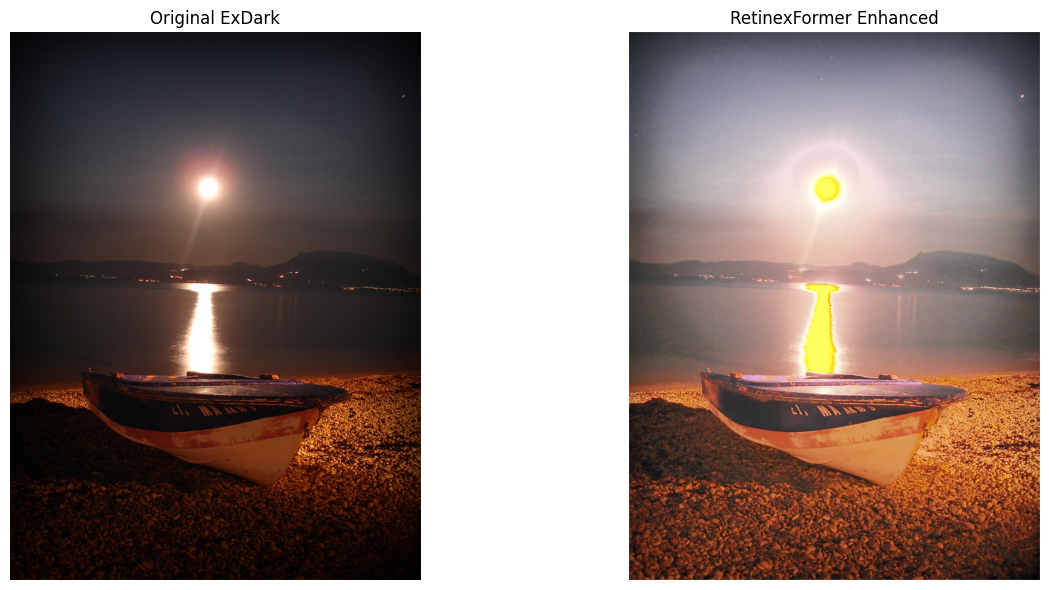

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open(
    "/kaggle/working/vehicle_dataset/Images/Boat/2015_01231.jpg"
)

enhanced = Image.open(
    "/kaggle/working/test_retinexformer.jpg"
)

print("Original size:", original.size)
print("Enhanced size:", enhanced.size)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original ExDark")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title("RetinexFormer Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
# শুধু একটি image enhance করার function

def enhance_one(input_path, output_path):

    img = cv2.imread(input_path)

    if img is None:
        print("Image not found:", input_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.float32(img) / 255.0

    tensor = torch.from_numpy(img).permute(2, 0, 1)
    tensor = tensor.unsqueeze(0).cuda()

    _, _, h, w = tensor.shape

    # Padding
    factor = 4
    new_h = ((h + factor - 1) // factor) * factor
    new_w = ((w + factor - 1) // factor) * factor

    tensor = F.pad(
        tensor,
        (0, new_w - w, 0, new_h - h),
        mode="reflect"
    )

    # RetinexFormer
    with torch.inference_mode():
        restored = model(tensor)

    # Remove padding
    restored = restored[:, :, :h, :w]

    # Convert back
    restored = torch.clamp(restored, 0, 1)
    restored = (
        restored.cpu()
        .permute(0, 2, 3, 1)
        .squeeze(0)
        .numpy()
    )

    restored = (restored * 255).astype(np.uint8)

    # Save
    Image.fromarray(restored).save(output_path)

    print("Done!")
    print("Original:", input_path)
    print("Enhanced:", output_path)
    print("Size:", (w, h))

In [37]:
input_path = "/kaggle/working/vehicle_dataset/Images/Boat/2015_00676.jpg"

output_path = "/kaggle/working/test_00676.jpg"

enhance_one(input_path, output_path)

Done!
Original: /kaggle/working/vehicle_dataset/Images/Boat/2015_00676.jpg
Enhanced: /kaggle/working/test_00676.jpg
Size: (640, 427)


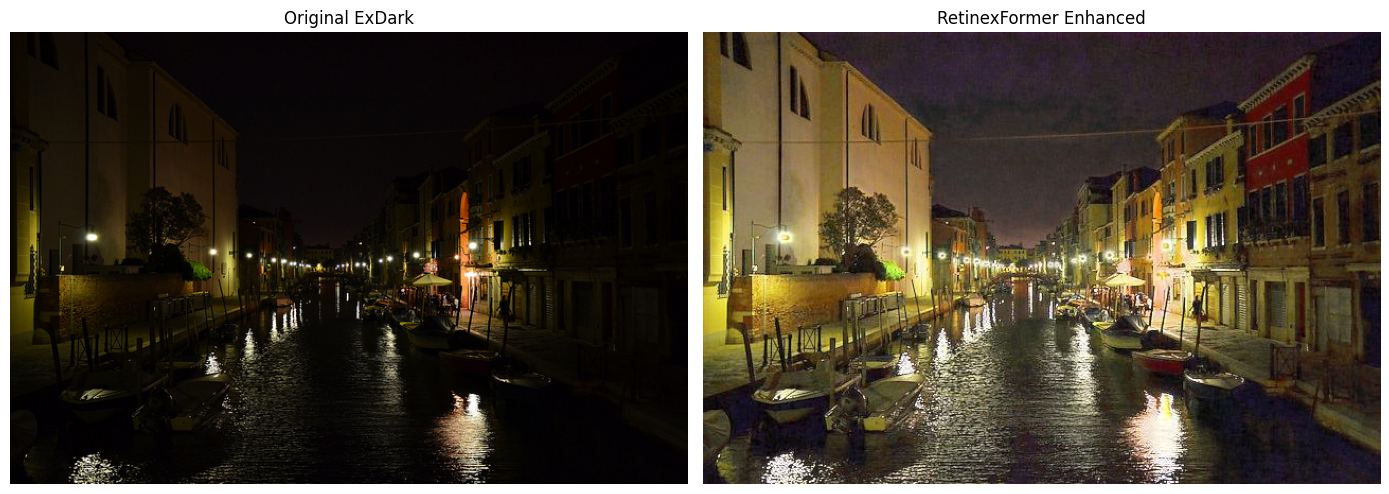

In [38]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open(input_path)
enhanced = Image.open(output_path)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original ExDark")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title("RetinexFormer Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm

# ============================================================
# INPUT / OUTPUT DIRECTORIES
# ============================================================

input_root = "/kaggle/working/vehicle_dataset/Images"

output_root = "/kaggle/working/enhanced_vehicle_dataset/Images"

# Create output directory
os.makedirs(output_root, exist_ok=True)

# Vehicle classes
classes = [
    "Bicycle",
    "Boat",
    "Bus",
    "Car",
    "Motorbike"
]

# ============================================================
# ENHANCEMENT FUNCTION
# ============================================================

def enhance_image(input_path, output_path):

    # Read image
    img = cv2.imread(input_path)

    if img is None:
        return False

    # BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to [0, 1]
    img = np.float32(img) / 255.0

    # Convert to tensor
    input_tensor = torch.from_numpy(img).permute(2, 0, 1)
    input_tensor = input_tensor.unsqueeze(0).cuda()

    # Original dimensions
    _, _, h, w = input_tensor.shape

    # RetinexFormer requires divisible by 4
    factor = 4

    new_h = ((h + factor - 1) // factor) * factor
    new_w = ((w + factor - 1) // factor) * factor

    pad_h = new_h - h
    pad_w = new_w - w

    # Padding
    if pad_h > 0 or pad_w > 0:
        input_tensor = F.pad(
            input_tensor,
            (0, pad_w, 0, pad_h),
            mode="reflect"
        )

    # ========================================================
    # RETINEXFORMER
    # ========================================================

    with torch.inference_mode():

        restored = model(input_tensor)

    # Remove padding
    restored = restored[:, :, :h, :w]

    # Clamp
    restored = torch.clamp(restored, 0, 1)

    # Tensor -> NumPy
    restored = (
        restored
        .cpu()
        .permute(0, 2, 3, 1)
        .squeeze(0)
        .numpy()
    )

    # [0,1] -> [0,255]
    restored = (restored * 255).astype(np.uint8)

    # RGB -> BGR for OpenCV
    restored = cv2.cvtColor(restored, cv2.COLOR_RGB2BGR)

    # Save
    cv2.imwrite(output_path, restored)

    return True


# ============================================================
# PROCESS ALL IMAGES
# ============================================================

total = 0
success = 0
failed = []

for class_name in classes:

    input_dir = os.path.join(input_root, class_name)
    output_dir = os.path.join(output_root, class_name)

    os.makedirs(output_dir, exist_ok=True)

    print(f"\nProcessing {class_name}...")

    image_files = []

    for filename in os.listdir(input_dir):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")
        ):
            image_files.append(filename)

    image_files.sort()

    for filename in tqdm(image_files):

        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, filename)

        total += 1

        try:

            result = enhance_image(
                input_path,
                output_path
            )

            if result:
                success += 1
            else:
                failed.append(filename)

        except Exception as e:

            failed.append(
                f"{class_name}/{filename} -> {str(e)}"
            )

# ============================================================
# RESULT
# ============================================================

print("\n" + "=" * 60)
print("RETINEXFORMER ENHANCEMENT COMPLETE")
print("=" * 60)

print("Total images:", total)
print("Successfully enhanced:", success)
print("Failed:", len(failed))

print("\nOutput directory:")
print(output_root)

if failed:
    print("\nFirst 10 failed images:")
    for item in failed[:10]:
        print(item)


Processing Bicycle...


100%|██████████| 651/651 [05:43<00:00,  1.89it/s]



Processing Boat...


100%|██████████| 679/679 [05:05<00:00,  2.22it/s]



Processing Bus...


...


Processing Car...


100%|██████████| 638/638 [05:25<00:00,  1.96it/s]



Processing Motorbike...


100%|██████████| 502/502 [03:48<00:00,  2.20it/s]


RETINEXFORMER ENHANCEMENT COMPLETE
Total images: 2997
Successfully enhanced: 2845
Failed: 152

Output directory:
/kaggle/working/enhanced_vehicle_dataset/Images

First 10 failed images:
Bicycle/2015_00148.jpg -> Caught OutOfMemoryError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/parallel_apply.py", line 103, in _worker
    output = module(*input, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Retinexformer/basicsr/models/archs/RetinexFormer_arch.py", line 358, in forward
    out = self.body(x)
 

In [40]:
!du -sh /kaggle/working/Retinexformer
!du -sh /kaggle/working/enhanced_vehicle_dataset
!du -sh /kaggle/working/filtered_annotations
!du -sh /kaggle/working/vehicle_dataset

32M	/kaggle/working/Retinexformer
580M	/kaggle/working/enhanced_vehicle_dataset
12M	/kaggle/working/filtered_annotations
680M	/kaggle/working/vehicle_dataset


In [41]:
import os
import shutil

source_root = "/kaggle/working"
checkpoint_dir = "/kaggle/working/vehicle_project_checkpoint"

# Remove previous checkpoint folder if it exists
if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)

os.makedirs(checkpoint_dir, exist_ok=True)

# Folders/files we actually need
items_to_save = [
    "Retinexformer",
    "enhanced_vehicle_dataset",
    "filtered_annotations",
    "vehicle_dataset",
    "test_00676.jpg",
    "test_00800.jpg",
    "test_retinexformer.jpg"
]

# Copy them into checkpoint folder
for item in items_to_save:
    src = os.path.join(source_root, item)
    dst = os.path.join(checkpoint_dir, item)

    if os.path.isdir(src):
        shutil.copytree(src, dst)
    elif os.path.isfile(src):
        shutil.copy2(src, dst)

print("✅ Clean checkpoint created!")
print()
print("Contents:")

for item in os.listdir(checkpoint_dir):
    print("  ├──", item)

print()

✅ Clean checkpoint created!

Contents:
  ├── Retinexformer
  ├── test_00800.jpg
  ├── filtered_annotations
  ├── test_retinexformer.jpg
  ├── test_00676.jpg
  ├── vehicle_dataset
  ├── enhanced_vehicle_dataset

